In [1]:
import numpy as np
import matplotlib.pyplot as plt

# pytorch stuff
import torch
import torch.nn as nn
from torch.nn import functional as F

from transformers import AutoModelForCausalLM, AutoTokenizer, get_linear_schedule_with_warmup

from torch.optim import AdamW

# for text printing
import textwrap

import requests

from time import process_time

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# Eleuther's tokenizer
tokenizer = AutoTokenizer.from_pretrained("EleutherAI/gpt-neo-125M")
tokenizer.pad_token_id = tokenizer.encode(' ')[0]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/357 [00:00<?, ?B/s]

In [4]:
# Load two GPT neo models
model_freeze = AutoModelForCausalLM.from_pretrained("EleutherAI/gpt-neo-125M").to(device)
model_train = AutoModelForCausalLM.from_pretrained("EleutherAI/gpt-neo-125M").to(device)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/526M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

# Download text

In [5]:
# Downlaod from the book Moby Dick from gutenberg.org
text = requests.get('https://www.gutenberg.org/files/2701/2701-0.txt').text
tokenized_data = tokenizer(text,return_tensors='pt').to(device)
tokens = tokenized_data['input_ids']
attention_mask = tokenized_data['attention_mask']

print(f'Moby Dick has {tokens.shape[1]:,} tokens of which there are {len(torch.unique(tokens)):,} unique tokens')

Token indices sequence length is longer than the specified maximum sequence length for this model (349340 > 2048). Running this sequence through the model will result in indexing errors


Moby Dick has 349,340 tokens of which there are 16,908 unique tokens


In [6]:
# Top 100 most frequent tokens from Moby Dick
tok, count = torch.unique(tokens[0], return_counts=True)
top100_idx = torch.argsort(count, descending=True)[:100]
top100_MB = tok[top100_idx]

print('Top 100 most frequent words in Moby Dick')
print('*'*20)
print('\n'.join(f'{tokenizer.decode(tok[idx]).strip():<8} {"occurs":<13} {count[idx]:>8,} times' for idx in top100_idx if len(tokenizer.decode(tok[idx]).strip())>2))


Top 100 most frequent words in Moby Dick
********************
the      occurs          12,996 times
and      occurs           5,646 times
that     occurs           2,737 times
his      occurs           2,351 times
with     occurs           1,558 times
was      occurs           1,550 times
all      occurs           1,375 times
for      occurs           1,337 times
this     occurs           1,179 times
not      occurs           1,026 times
but      occurs           1,021 times
him      occurs           1,000 times
from     occurs             984 times
whale    occurs             843 times
one      occurs             841 times
the      occurs             835 times
you      occurs             783 times
have     occurs             720 times
had      occurs             719 times
were     occurs             641 times
there    occurs             637 times
now      occurs             598 times
which    occurs             571 times
their    occurs             570 times
some     occurs           

# Quantative evaluation of the model
- by counting the pecentage of tokens from Top 100 tokens that are generated by the model

In [7]:
# Function to calculate pre/ post-train token usage from Top 100 to quantitatively evaluate the models

from transformers import set_seed

@torch.no_grad()
def top100_usage_percent(model, randstarts, top100_ids, tokenizer, numtoks=100, device="cuda", seed=0):
    """
    Returns: percentage of generated tokens that are in top100_ids (tensor of token ids).
    """
    model.eval()

    # Make sampling reproducible
    set_seed(seed)

    # Generate exactly 1(prompt) + numtoks tokens
    out = model.generate(
        randstarts,
        max_length=numtoks + 1,
        min_length=numtoks + 1,
        do_sample=True,
        bad_words_ids=[[tokenizer.eos_token_id]],  # robust EOS blocking
        pad_token_id=tokenizer.eos_token_id,
    )

    # Drop the prompt token and flatten
    gen = out[:, 1:].reshape(-1)

    # Compute percent in top100 list
    # torch.isin is available in newer torch; if not, we can fallback.
    pct = 100.0 * torch.isin(gen, top100_ids.to(gen.device)).float().mean().item()
    return pct

In [8]:
numreps = 10
numtoks = 100

# Generate random 1-token prompts
randstarts = torch.randint(0, tokenizer.vocab_size, (numreps, 1), device=device)

# Initialize array to store the percentage usage in pre/ post-train
tokenusage = np.zeros((2,2),dtype=float) # (pre/post-train, freeze/train model)

# Store pre-train percentage for freeze model
tokenusage[0,0] = top100_usage_percent(model_freeze,randstarts, top100_MB, tokenizer, numtoks=numtoks, device=device, seed=42)

# Store pre-train percentage for trained model
tokenusage[0,1] = top100_usage_percent(model_train, randstarts, top100_MB, tokenizer, numtoks=numtoks, device=device, seed=42)

print(tokenusage)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


[[37.00000048 37.00000048]
 [ 0.          0.        ]]


# Freeze Weights
- Train the attention weights (QKV) in layers 6+ and freeze the rest

In [9]:
!pip install torchinfo
from torchinfo import summary

In [10]:
# Analyze the paarmeters
from torchinfo import summary, ColumnSettings
summary(model=model_freeze,
        input_data={'input_ids': tokenized_data['input_ids'][:, :512], 'attention_mask': tokenized_data['attention_mask'][:, :512]},
        col_names=["input_size","output_size","num_params","trainable"],row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape               Output Shape              Param #                   Trainable
GPTNeoForCausalLM (GPTNeoForCausalLM)                        --                        --                        --                        True
├─GPTNeoModel (transformer)                                  [1, 512]                  --                        --                        True
│    └─Embedding (wte)                                       [1, 512]                  [1, 512, 768]             38,597,376                True
│    └─Embedding (wpe)                                       [1, 512]                  [1, 512, 768]             1,572,864                 True
│    └─Dropout (drop)                                        [1, 512, 768]             [1, 512, 768]             --                        --
│    └─ModuleList (h)                                        --                        --                        --                  

In [11]:
for p in model_freeze.parameters():
    p.requires_grad = False

for name, p in model_freeze.transformer.h[6:].named_parameters():
    if any(s in name for s in ['q_proj','k_proj','v_proj']):
        p.requires_grad = True
#

In [12]:
trainable = [n for n,p in model_freeze.named_parameters() if p.requires_grad]
print("\n".join(trainable))
print("Trainable tensors:", len(trainable))

transformer.h.6.attn.attention.k_proj.weight
transformer.h.6.attn.attention.v_proj.weight
transformer.h.6.attn.attention.q_proj.weight
transformer.h.7.attn.attention.k_proj.weight
transformer.h.7.attn.attention.v_proj.weight
transformer.h.7.attn.attention.q_proj.weight
transformer.h.8.attn.attention.k_proj.weight
transformer.h.8.attn.attention.v_proj.weight
transformer.h.8.attn.attention.q_proj.weight
transformer.h.9.attn.attention.k_proj.weight
transformer.h.9.attn.attention.v_proj.weight
transformer.h.9.attn.attention.q_proj.weight
transformer.h.10.attn.attention.k_proj.weight
transformer.h.10.attn.attention.v_proj.weight
transformer.h.10.attn.attention.q_proj.weight
transformer.h.11.attn.attention.k_proj.weight
transformer.h.11.attn.attention.v_proj.weight
transformer.h.11.attn.attention.q_proj.weight
Trainable tensors: 18


In [13]:
# Analyze the paarmeters
from torchinfo import summary, ColumnSettings
summary(model=model_freeze,
        input_data={'input_ids': tokenized_data['input_ids'][:, :512], 'attention_mask': tokenized_data['attention_mask'][:, :512]},
        col_names=["input_size","output_size","trainable"],row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape               Output Shape              Trainable
GPTNeoForCausalLM (GPTNeoForCausalLM)                        --                        --                        Partial
├─GPTNeoModel (transformer)                                  [1, 512]                  --                        Partial
│    └─Embedding (wte)                                       [1, 512]                  [1, 512, 768]             False
│    └─Embedding (wpe)                                       [1, 512]                  [1, 512, 768]             False
│    └─Dropout (drop)                                        [1, 512, 768]             [1, 512, 768]             --
│    └─ModuleList (h)                                        --                        --                        Partial
│    │    └─GPTNeoBlock (0)                                  [1, 512, 768]             [1, 512, 768]             False
│    │    └─GPTNeoBlock (1)              

# Train the model

In [14]:
model_freeze.transformer.h[5].attn.attention.k_proj.weight

Parameter containing:
tensor([[-0.0271, -0.3184,  0.2100,  ..., -0.0732, -0.2559, -0.0625],
        [-0.2041, -0.3242, -0.1348,  ..., -0.0011,  0.0459,  0.0923],
        [-0.6406, -0.2832,  0.1660,  ...,  0.1426, -0.3438, -0.2852],
        ...,
        [-0.1641,  0.1289, -0.0991,  ...,  0.2354, -0.0315,  0.1650],
        [ 0.0525,  0.0413,  0.2422,  ...,  0.0041,  0.0175,  0.2578],
        [ 0.2021,  0.2441,  0.5156,  ..., -0.1206,  0.2002, -0.0171]],
       device='cuda:0')

In [15]:
from torch.nn.utils import weight_norm
# Function to train the model

def trainLLM(num_steps, seq_len, batch_size, tokens, model, optimizer, print_weights=False):
    model.train()
    train_loss = np.zeros(num_steps)
    weight_norm = np.zeros(num_steps)

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=max(1, int(0.1 * num_steps)),
        num_training_steps=num_steps
    )

    for step in range(num_steps):

      # Save the weights for K for transformer layer 7
      k_weight_before_step = model.transformer.h[6].attn.attention.k_proj.weight.clone()

      ix = torch.randint(len(tokens) - seq_len, size=(batch_size,))
      X  = tokens[ix[:, None] + torch.arange(seq_len)].to(device)

      optimizer.zero_grad(set_to_none=True)

      outputs = model(X, labels=X)
      loss = outputs.loss
      loss.backward()

      torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

      optimizer.step()
      scheduler.step()

      k_weight_after_step = model.transformer.h[6].attn.attention.k_proj.weight.detach()

      k_weight_norm = torch.norm(k_weight_before_step - k_weight_after_step)

      weight_norm[step] = k_weight_norm.item()

      if print_weights and step % 50 == 0:
        print('Change in weight:', k_weight_norm.item())

      train_loss[step] = loss.item()
      if step % 50 == 0:
          print(f"Step {step:4}/{num_steps}, loss: {loss.item():.4f}")

    return train_loss, weight_norm

In [16]:
# Train the freeze model

learning_rate = 5e-4
optimizer_freeze = torch.optim.AdamW(
    model_freeze.parameters(),
    lr=learning_rate,
    weight_decay=0.01
)

start_time = process_time()

freeze_loss, weight_norm_freeze = trainLLM(
    num_steps=476,
    seq_len=256,
    batch_size=32,
    tokens=tokens[0],
    model=model_freeze,
    optimizer=optimizer_freeze,
    print_weights=False
)

elapsed_time = process_time() - start_time
print(f"Training time: {elapsed_time:.2f} seconds")

Step    0/476, loss: 3.6471
Step   50/476, loss: 3.4660
Step  100/476, loss: 3.3973
Step  150/476, loss: 3.3375
Step  200/476, loss: 3.2583
Step  250/476, loss: 3.2881
Step  300/476, loss: 3.2509
Step  350/476, loss: 3.1619
Step  400/476, loss: 3.2155
Step  450/476, loss: 3.1841
Training time: 129.43 seconds


In [17]:
# Train the trainable model

learning_rate = 5e-4
optimizer_train = torch.optim.AdamW(
    model_train.parameters(),
    lr=learning_rate,
    weight_decay=0.01
)

start_time = process_time()

train_losses, weight_norm_train = trainLLM(
    num_steps=476,
    seq_len=256,
    batch_size=32,
    tokens=tokens[0],
    model=model_train,
    optimizer=optimizer_train,
    print_weights=False
)

elapsed_time = process_time() - start_time
print(f"Training time: {elapsed_time:.2f} seconds")

Step    0/476, loss: 3.6574
Step   50/476, loss: 2.9695
Step  100/476, loss: 2.5513
Step  150/476, loss: 1.9577
Step  200/476, loss: 1.5986
Step  250/476, loss: 1.3304
Step  300/476, loss: 0.8808
Step  350/476, loss: 0.7821
Step  400/476, loss: 0.7008
Step  450/476, loss: 0.4638
Training time: 217.08 seconds


# Visualize the results

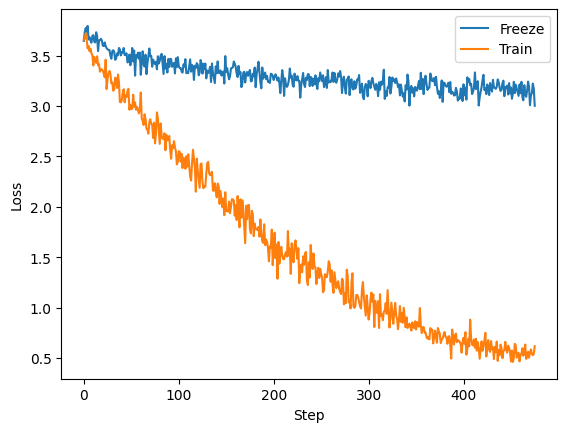

In [18]:
# Plot the losses for both the models
plt.plot(freeze_loss, label='Freeze')
plt.plot(train_losses, label='Train')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.legend()
plt.show()

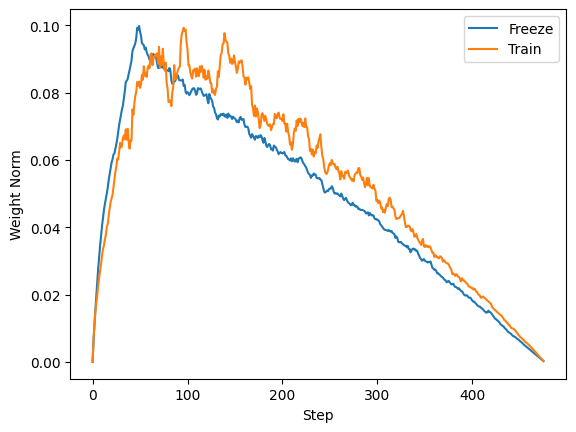

In [19]:
# Plot the weight norms for both the models
plt.plot(weight_norm_freeze, label='Freeze')
plt.plot(weight_norm_train, label='Train')
plt.xlabel('Step')
plt.ylabel('Weight Norm')
plt.legend()
plt.show()
#

In [20]:
# Toekn usages of both the models post training
tokenusage[1,0] = top100_usage_percent(model_freeze,randstarts, top100_MB, tokenizer, numtoks=numtoks, device=device, seed=42)
tokenusage[1,1] = top100_usage_percent(model_train, randstarts, top100_MB, tokenizer, numtoks=numtoks, device=device, seed=42)

print(tokenusage)
#

[[37.00000048 37.00000048]
 [64.90000486 57.80000091]]


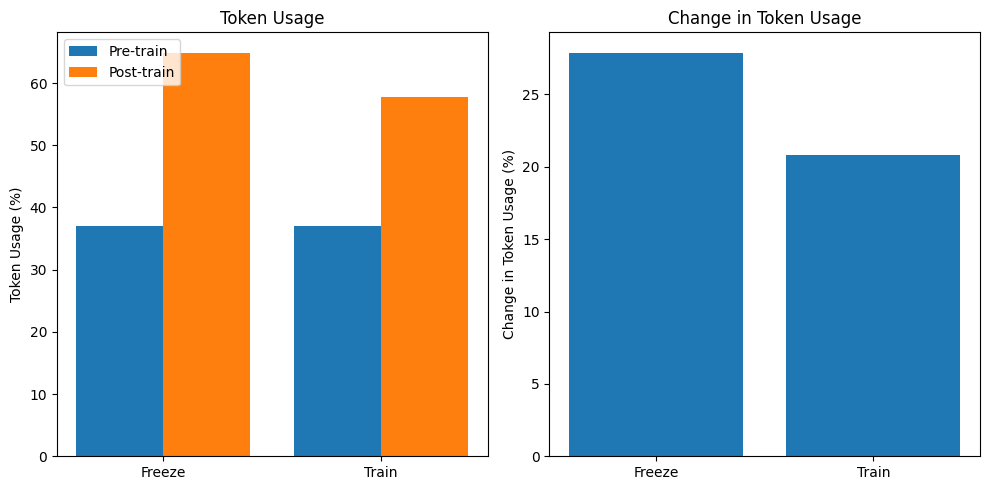

In [30]:
# Plot the token usages through bar plots
_, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].bar([.8,1.8],tokenusage[0,:],width=0.4,label='Pre-train')
axs[0].bar([1.2,2.2],tokenusage[1,:],width=0.4,label='Post-train')
axs[0].set_xticks([1,2])
axs[0].set_xticklabels(['Freeze','Train'])
axs[0].set_ylabel('Token Usage (%)')
axs[0].set_title('Token Usage')
axs[0].legend(loc="upper left")

axs[1].bar([1,2],np.diff(tokenusage,axis=0)[0])
axs[1].set_xticks([1,2])
axs[1].set_xticklabels(['Freeze','Train'])
axs[1].set_ylabel('Change in Token Usage (%)')
axs[1].set_title('Change in Token Usage')

plt.tight_layout()
plt.show()

# Swith the frozen layers

- Train the attention weights (QKV) in layers 0-5 and freeze the rest

In [31]:
for p in model_freeze.parameters():
    p.requires_grad = True

for name, p in model_freeze.transformer.h[6:].named_parameters():
    if any(s in name for s in ['q_proj','k_proj','v_proj']):
        p.requires_grad = False
#

In [33]:
trainable = [n for n,p in model_freeze.named_parameters() if not p.requires_grad]
print("\n".join(trainable))
print("Trainable tensors:", len(trainable))

transformer.h.6.attn.attention.k_proj.weight
transformer.h.6.attn.attention.v_proj.weight
transformer.h.6.attn.attention.q_proj.weight
transformer.h.7.attn.attention.k_proj.weight
transformer.h.7.attn.attention.v_proj.weight
transformer.h.7.attn.attention.q_proj.weight
transformer.h.8.attn.attention.k_proj.weight
transformer.h.8.attn.attention.v_proj.weight
transformer.h.8.attn.attention.q_proj.weight
transformer.h.9.attn.attention.k_proj.weight
transformer.h.9.attn.attention.v_proj.weight
transformer.h.9.attn.attention.q_proj.weight
transformer.h.10.attn.attention.k_proj.weight
transformer.h.10.attn.attention.v_proj.weight
transformer.h.10.attn.attention.q_proj.weight
transformer.h.11.attn.attention.k_proj.weight
transformer.h.11.attn.attention.v_proj.weight
transformer.h.11.attn.attention.q_proj.weight
Trainable tensors: 18


In [34]:
# Train the freeze model

learning_rate = 5e-4
optimizer_freeze = torch.optim.AdamW(
    model_freeze.parameters(),
    lr=learning_rate,
    weight_decay=0.01
)

start_time = process_time()

freeze_loss, weight_norm_freeze = trainLLM(
    num_steps=476,
    seq_len=256,
    batch_size=32,
    tokens=tokens[0],
    model=model_freeze,
    optimizer=optimizer_freeze,
    print_weights=False
)

elapsed_time = process_time() - start_time
print(f"Training time: {elapsed_time:.2f} seconds")

Step    0/476, loss: 3.0911
Step   50/476, loss: 2.8676
Step  100/476, loss: 2.3723
Step  150/476, loss: 1.8041
Step  200/476, loss: 1.6265
Step  250/476, loss: 1.4166
Step  300/476, loss: 1.1225
Step  350/476, loss: 0.7605
Step  400/476, loss: 0.7802
Step  450/476, loss: 0.6806
Training time: 211.20 seconds


In [35]:
# Train the trainable model

learning_rate = 5e-4
optimizer_train = torch.optim.AdamW(
    model_train.parameters(),
    lr=learning_rate,
    weight_decay=0.01
)

start_time = process_time()

train_losses, weight_norm_train = trainLLM(
    num_steps=476,
    seq_len=256,
    batch_size=32,
    tokens=tokens[0],
    model=model_train,
    optimizer=optimizer_train,
    print_weights=False
)

elapsed_time = process_time() - start_time
print(f"Training time: {elapsed_time:.2f} seconds")

Step    0/476, loss: 0.5542
Step   50/476, loss: 0.4709
Step  100/476, loss: 0.4669
Step  150/476, loss: 0.3449
Step  200/476, loss: 0.3348
Step  250/476, loss: 0.2737
Step  300/476, loss: 0.1980
Step  350/476, loss: 0.1856
Step  400/476, loss: 0.1728
Step  450/476, loss: 0.1448
Training time: 217.03 seconds


# Visualize the results

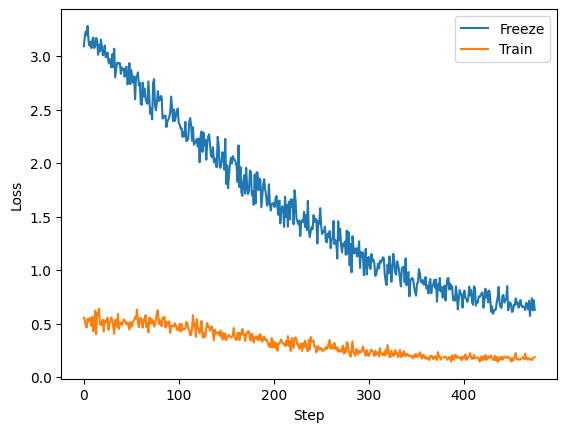

In [36]:
# Plot the losses for both the models
plt.plot(freeze_loss, label='Freeze')
plt.plot(train_losses, label='Train')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.legend()
plt.show()

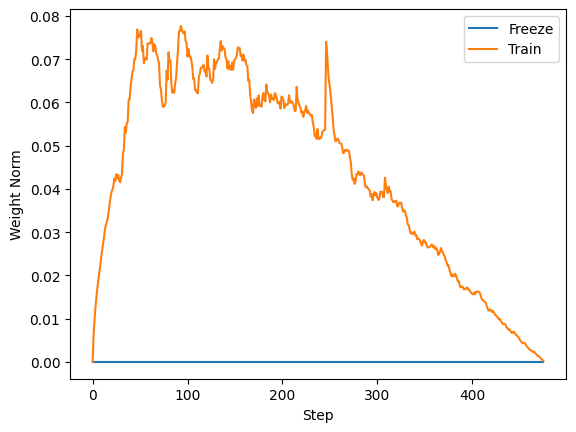

In [37]:
# Plot the weight norms for both the models
plt.plot(weight_norm_freeze, label='Freeze')
plt.plot(weight_norm_train, label='Train')
plt.xlabel('Step')
plt.ylabel('Weight Norm')
plt.legend()
plt.show()
#

In [38]:
# Token usages of both the models post training
tokenusage[1,0] = top100_usage_percent(model_freeze,randstarts, top100_MB, tokenizer, numtoks=numtoks, device=device, seed=42)
tokenusage[1,1] = top100_usage_percent(model_train, randstarts, top100_MB, tokenizer, numtoks=numtoks, device=device, seed=42)

print(tokenusage)
#

[[37.00000048 37.00000048]
 [56.60000443 59.20000076]]


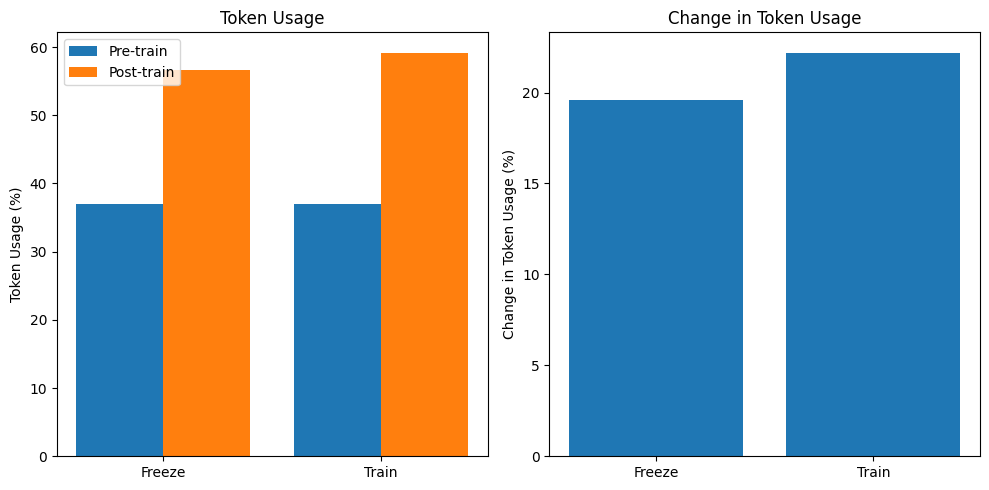

In [39]:
# Plot the token usages through bar plots
_, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].bar([.8,1.8],tokenusage[0,:],width=0.4,label='Pre-train')
axs[0].bar([1.2,2.2],tokenusage[1,:],width=0.4,label='Post-train')
axs[0].set_xticks([1,2])
axs[0].set_xticklabels(['Freeze','Train'])
axs[0].set_ylabel('Token Usage (%)')
axs[0].set_title('Token Usage')
axs[0].legend(loc="upper left")

axs[1].bar([1,2],np.diff(tokenusage,axis=0)[0])
axs[1].set_xticks([1,2])
axs[1].set_xticklabels(['Freeze','Train'])
axs[1].set_ylabel('Change in Token Usage (%)')
axs[1].set_title('Change in Token Usage')

plt.tight_layout()
plt.show()